# Peak-to-Gene Linkage


`epione.tl.peak_to_gene` ports ArchR's `addPeak2GeneLinks`: kNN metacells over a joint embedding → mean-aggregate peak and gene matrices → per-pair Pearson correlation with Student-t + BH FDR.

`epione.pl.plot_peak2gene` renders an ArchR-style browser track — per-group pseudobulk coverage, peaks, half-ellipse link arcs, and a UCSC-style gene model — **without requiring BigWig files**.


## Data Preparation

snapatac2 bundles pre-processed h5ad files of the 10x PBMC 10k multiome dataset. ATAC and RNA share barcodes — keep the intersection.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, pathlib
os.environ['XDG_CACHE_HOME'] = '/scratch/users/steorra/cache'

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import snapatac2 as snap
from IPython.display import display
import epione as epi
import matplotlib.pyplot as plt

epi.pl.plot_set()

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc10k_p2g')
WORK.mkdir(parents=True, exist_ok=True)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /scratch/users/steorra/env/omicdev/lib/python3.10/site-packages
  warnings.warn(


In [2]:
atac = ad.read_h5ad(str(snap.datasets.pbmc10k_multiome(modality='ATAC', type='h5ad')))
rna  = ad.read_h5ad(str(snap.datasets.pbmc10k_multiome(modality='RNA',  type='h5ad')))
print(atac)
print(rna)


AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'cell_type'
    var: 'feature_types'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap'
AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'cell_type'
    var: 'gene_ids', 'feature_types'


In [3]:
common = atac.obs_names.intersection(rna.obs_names)
atac = atac[common].copy()
rna  = rna[common].copy()
atac.obs['n_fragment'] = np.asarray(atac.X.sum(axis=1)).ravel()
atac.shape, rna.shape


((9631, 107194), (9631, 29095))

## Iterative LSI on the ATAC matrix

`peak_to_gene` needs a dense low-dimensional embedding to build kNN metacells from. Iterative LSI is the canonical choice for scATAC.


In [4]:
%%time
epi.tl.iterative_lsi(
    atac,
    n_components=30,
    iterations=2,
    var_features=25_000,
    resolution=0.5,
    n_neighbors=30,
    sample_cells_pre=10_000,
    depth_col='n_fragment',
    seed=1,
)
atac.obsm['X_iterative_lsi'].shape


  └─ [iterative_lsi] Initial feature set: 106,658 / 107,194


  └─ [iterative_lsi] Iter 1/2 | fit on 9,631 cells x 106,658 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:31)


running Leiden clustering


    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 15 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 9,631 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (9,631 x 29) in adata.obsm['X_iterative_lsi']
CPU times: user 1min 31s, sys: 4.78 s, total: 1min 36s
Wall time: 58.6 s


(9631, 29)

## Gene annotation

Per-gene coordinates define the ±`max_distance` window around each TSS. snapatac2 ships a cached GENCODE hg38 GFF3.


In [5]:
import pyranges as pr
gtf_path = snap.genome.hg38.annotation
g = pr.read_gff3(str(gtf_path)).df

gene_ann = pd.DataFrame({
    'gene_name': g.loc[g.Feature == 'gene', 'gene_name'].astype(str).values,
    'chrom':     g.loc[g.Feature == 'gene', 'Chromosome'].astype(str).values,
    'start':     g.loc[g.Feature == 'gene', 'Start'].astype(int).values,
    'end':       g.loc[g.Feature == 'gene', 'End'].astype(int).values,
    'strand':    g.loc[g.Feature == 'gene', 'Strand'].astype(str).values,
}).drop_duplicates('gene_name').reset_index(drop=True)

exon_ann = pd.DataFrame({
    'gene_name': g.loc[g.Feature == 'exon', 'gene_name'].astype(str).values,
    'chrom':     g.loc[g.Feature == 'exon', 'Chromosome'].astype(str).values,
    'start':     g.loc[g.Feature == 'exon', 'Start'].astype(int).values,
    'end':       g.loc[g.Feature == 'exon', 'End'].astype(int).values,
    'strand':    g.loc[g.Feature == 'exon', 'Strand'].astype(str).values,
})

len(gene_ann), len(exon_ann)


(60606, 839796)

## Peak-to-gene

ArchR defaults: 500 metacells × 100 neighbours, ±250 kb window, Pearson correlation, BH FDR across all tested pairs.


In [6]:
%%time
links = epi.tl.peak_to_gene(
    atac,
    rna=rna,
    gene_annotation=gene_ann,
    use_rep='X_iterative_lsi',
    n_metacells=500,
    k_neighbors=100,
    max_distance=250_000,
    seed=1,
)
links.to_parquet(WORK / 'peak_to_gene.parquet')
print(f'{len(links):,} pairs | {(links.fdr < 0.05).sum():,} FDR < 0.05')


  └─ [peak_to_gene] 107,194 peaks | 20,169 annotated genes | 9,631 cells
  └─ [peak_to_gene] Building 500 metacells × 100 neighbours from X_iterative_lsi
  └─ [peak_to_gene] Aggregating peak matrix


  └─ [peak_to_gene] Aggregating gene matrix


  └─ [peak_to_gene] Finding peak-gene pairs within ±250,000 bp


  └─ [peak_to_gene] 726,292 candidate pairs
  └─ [peak_to_gene] Computing correlations


  └─ [peak_to_gene] 726,292 pairs retained, 441,142 significant (FDR < 0.05)


726,292 pairs | 441,142 FDR < 0.05
CPU times: user 4.67 s, sys: 2.34 s, total: 7.01 s
Wall time: 6.25 s


In [7]:
links.reindex(links['correlation'].abs().sort_values(ascending=False).index) \
     .head(10)[['peak', 'gene', 'distance', 'correlation', 'fdr']]


,peak,gene,distance,correlation,fdr
652165,chr7:101367780-101367789,LINC01007,-201222,0.999998,0.0
652164,chr7:101367780-101367789,COL26A1,4910,0.999798,0.0
467543,chr20:9388473-9388582,LAMP5-AS1,-126471,0.999493,0.0
467542,chr20:9388473-9388582,LAMP5,-125830,0.998663,0.0
360128,chr19:5336190-5336587,PTPRS,-4424,0.998541,0.0
89849,chr10:89809057-89809192,LINC01374,-44470,0.998295,0.0
100520,chr11:634199-634286,SCT,7061,0.997344,0.0
679193,chr8:134625591-134625702,ZFAT-AS1,27576,0.997196,0.0
237289,chr15:75018870-75019357,SCAMP5,61895,0.996811,0.0
679199,chr8:134683132-134683772,ZFAT-AS1,85382,0.996300,0.0


### Summary plots


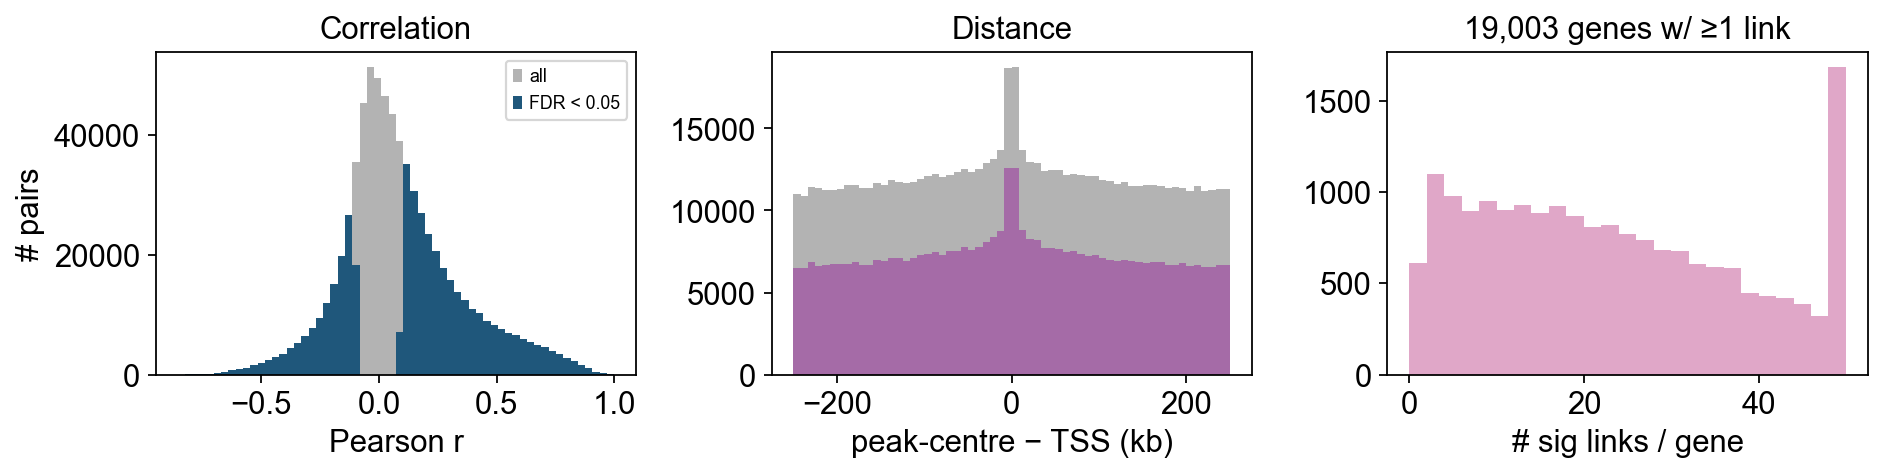

In [8]:
sig = links[links['fdr'] < 0.05]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

axes[0].hist(links['correlation'],  bins=60, color='0.7', label='all')
axes[0].hist(sig['correlation'],    bins=60, color='C0',  label='FDR < 0.05')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('# pairs')
axes[0].legend(fontsize=8); axes[0].set_title('Correlation')

axes[1].hist(links['distance'] / 1e3, bins=60, color='0.7')
axes[1].hist(sig['distance']   / 1e3, bins=60, color='C1')
axes[1].set_xlabel('peak-centre − TSS (kb)'); axes[1].set_title('Distance')

per_gene = sig.groupby('gene').size().clip(upper=50)
axes[2].hist(per_gene, bins=np.arange(0, 52, 2), color='C2')
axes[2].set_xlabel('# sig links / gene')
axes[2].set_title(f'{per_gene.size:,} genes w/ ≥1 link')

plt.tight_layout(); display(fig); plt.close(fig)


In [9]:
for gene in ['CD3D', 'CD19', 'MS4A1', 'GNLY', 'LYZ']:
    sub = sig[sig['gene'] == gene]
    if sub.empty:
        continue
    print(f'\n{gene}: {len(sub)} significant links')
    print(sub.reindex(sub.correlation.abs().sort_values(ascending=False).index)
             .head(5)[['peak', 'distance', 'correlation']].to_string(index=False))



CD3D: 52 significant links
                     peak  distance  correlation
chr11:118337765-118347252      -197     0.882967
chr11:118304165-118308090    -36578     0.849636
chr11:118315296-118317685    -26215     0.779693
chr11:118398435-118402795     57910     0.710349
chr11:118434093-118439206     93944     0.694896

CD19: 44 significant links
                   peak  distance  correlation
chr16:28910024-28911110    -21397     0.913139
chr16:28930484-28933437        -4     0.874558
chr16:28923628-28926451     -6925     0.711179
chr16:28902003-28904135    -28895     0.576940
chr16:29007438-29010500     77005    -0.428174

MS4A1: 40 significant links
                   peak  distance  correlation
chr11:60455290-60456088      -156     0.958685
chr11:60498212-60499391     42956     0.917259
chr11:60457557-60458006      1936     0.904648
chr11:60485853-60486383     30273     0.900626
chr11:60459521-60459691      3761     0.883234

GNLY: 53 significant links
                  peak  dista

## Visualise links

`epi.pl.plot_peak2gene` draws coverage + peaks + link arcs + gene track on a genomic window around a gene. By default no BigWig files are required — per-group coverage is computed on the fly from the peak matrix with per-cell CP10k normalisation.


In [10]:
# Map fine-grained cell types to broad lineages for clearer coverage
major = {
    'CD4 Naive': 'T_CD4', 'CD4 TCM': 'T_CD4', 'CD4 TEM': 'T_CD4', 'Treg': 'T_CD4',
    'CD8 Naive': 'T_CD8', 'CD8 TEM_1': 'T_CD8', 'CD8 TEM_2': 'T_CD8',
    'MAIT': 'T_CD8', 'gdT': 'T_CD8',
    'Naive B': 'B', 'Memory B': 'B', 'Intermediate B': 'B', 'Plasma': 'B',
    'NK': 'NK', 'CD14 Mono': 'Mono', 'CD16 Mono': 'Mono',
    'cDC': 'DC', 'pDC': 'DC', 'HSPC': 'HSPC',
}
atac.obs['lineage'] = atac.obs['cell_type'].map(major).astype('category')


### Minimal: arcs + peaks + gene track


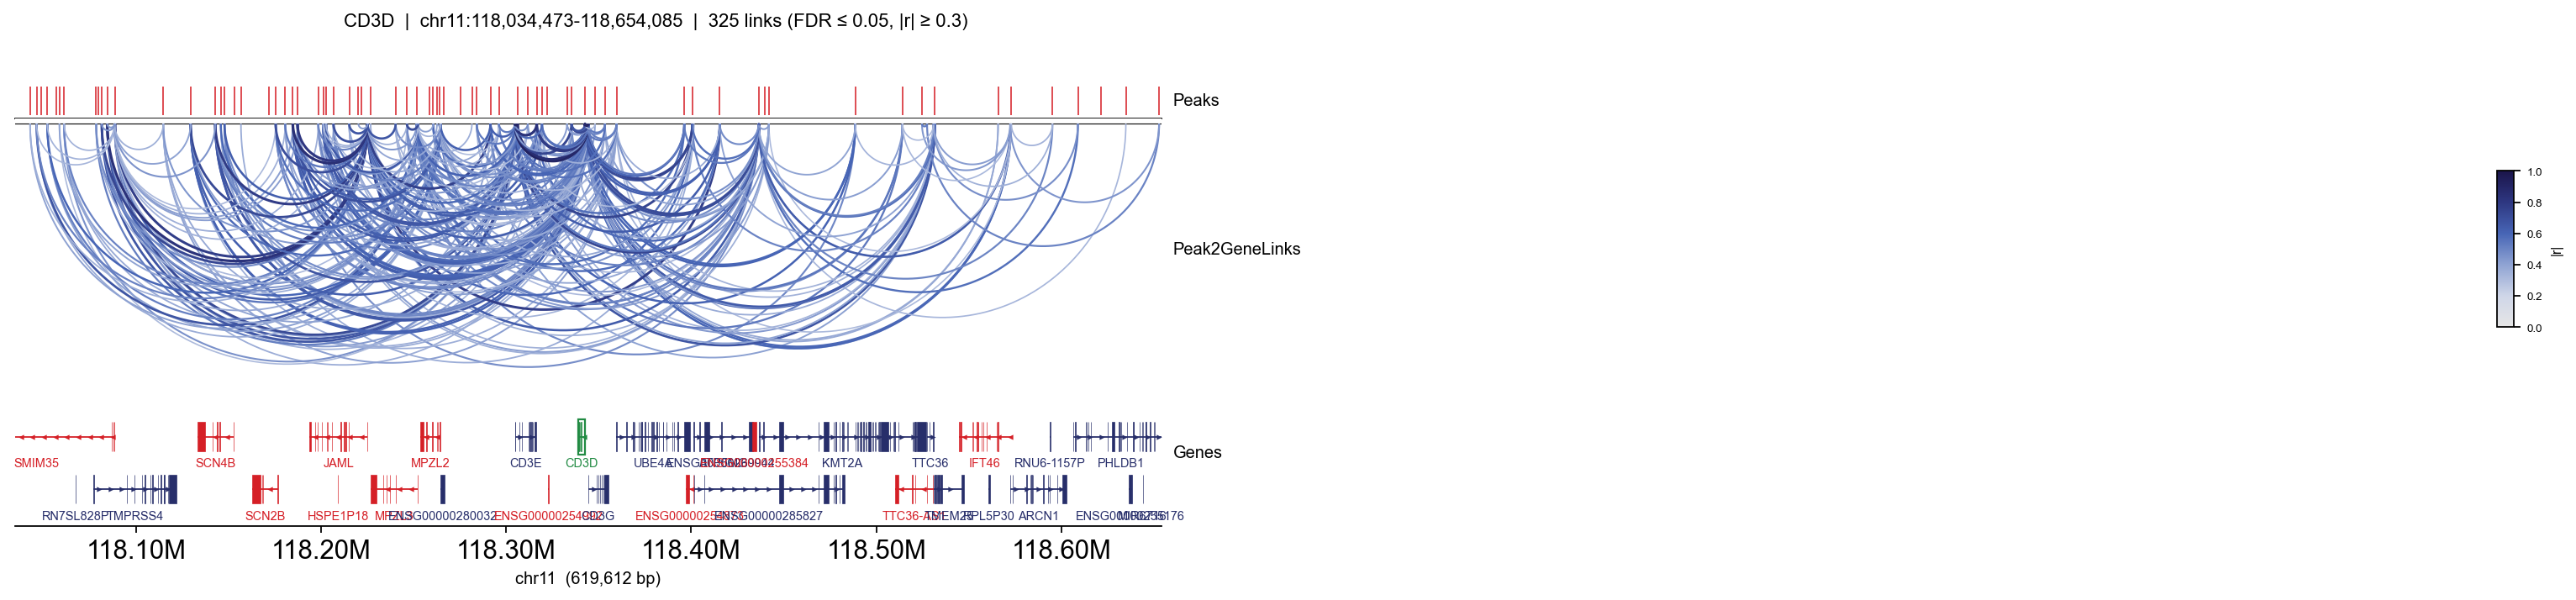

In [11]:
fig, _ = epi.pl.plot_peak2gene(
    atac, gene='CD3D',
    gene_annotation=gene_ann,
    exon_annotation=exon_ann,
    fdr_thresh=0.05, min_abs_r=0.3,
    pad_bp=80_000, figsize=(10, 4.5), show=False,
)
plt.tight_layout(); display(fig); plt.close(fig)


### Full track — per-lineage coverage

Passing `group_by=` adds one coverage row per category (per-cell CP10k-normalised, mean within group — so T-specific peaks appear clearly in T lineages and not elsewhere).


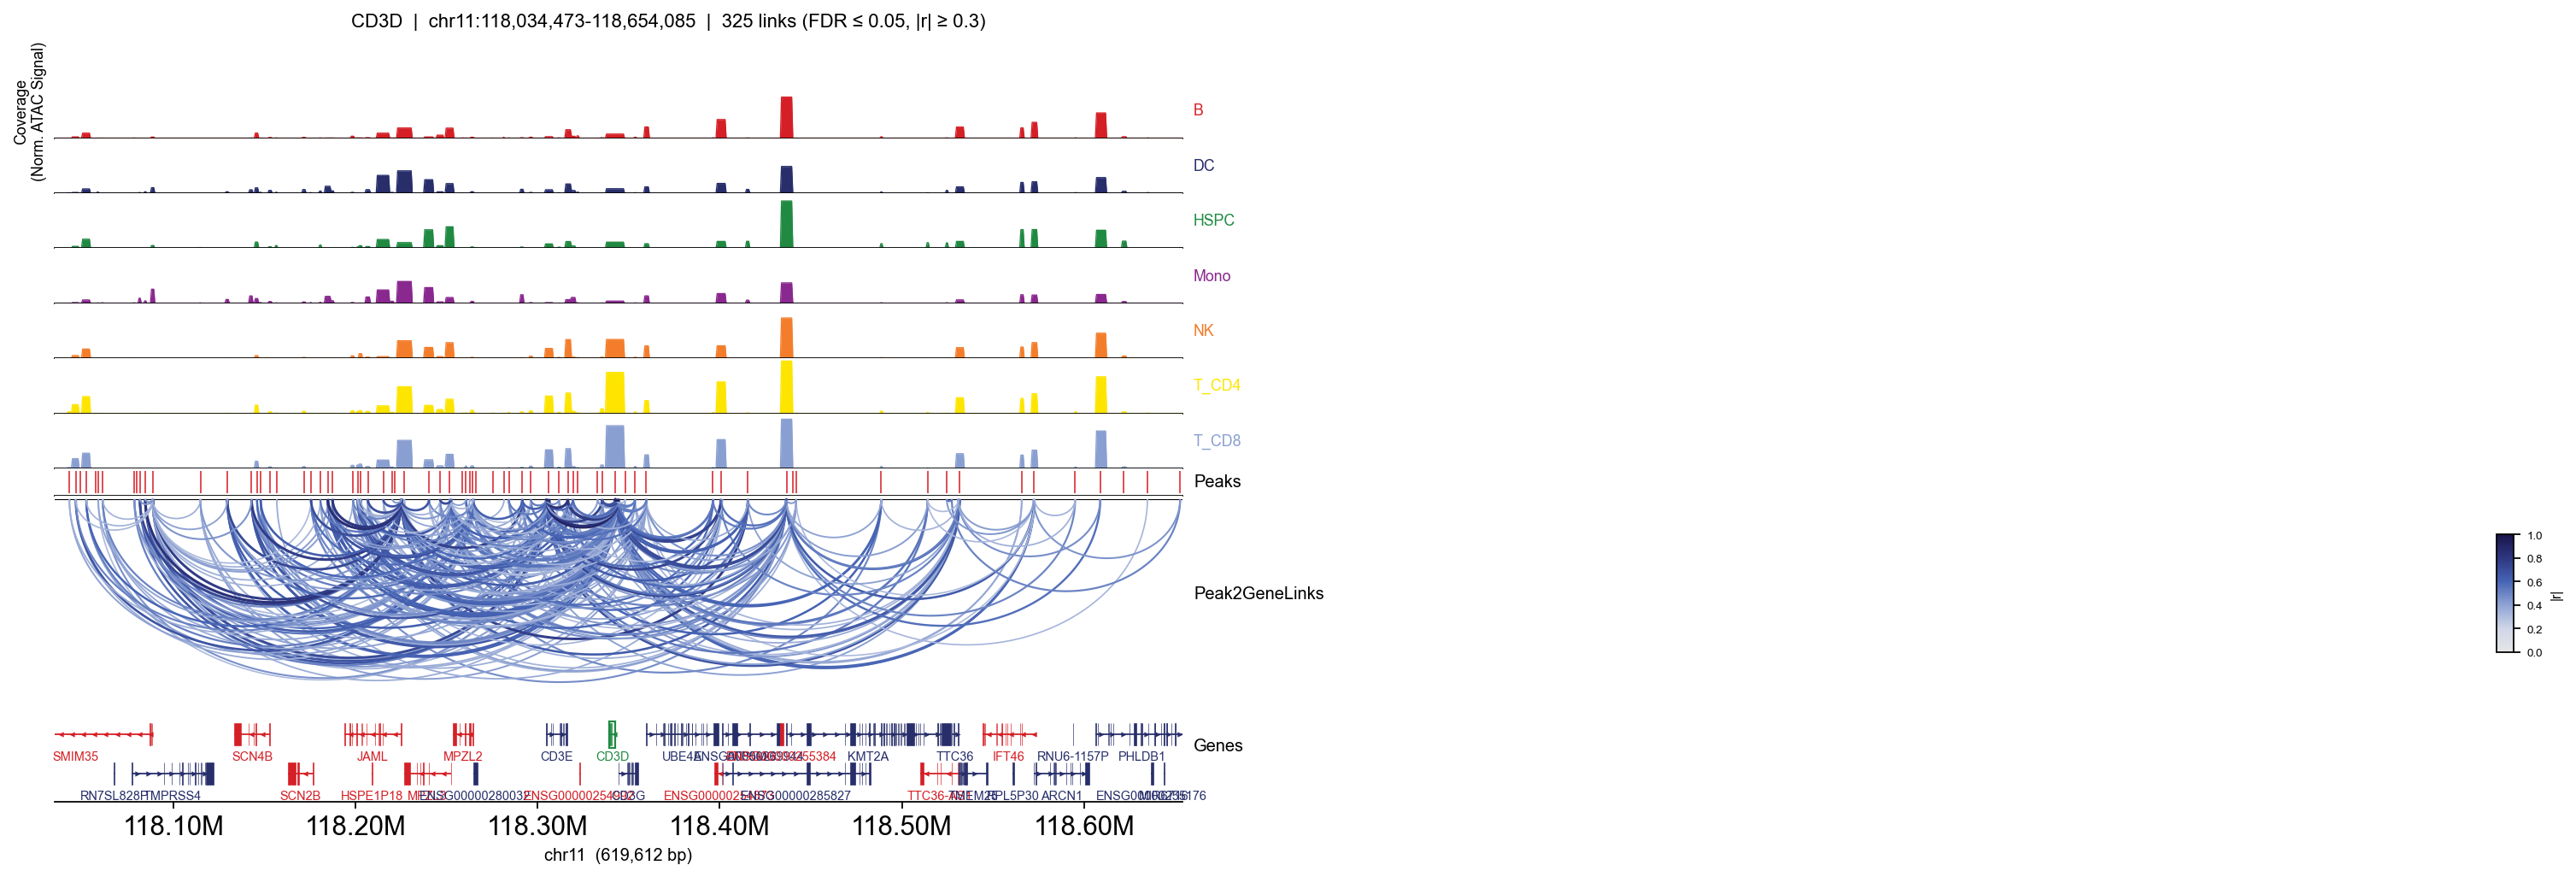

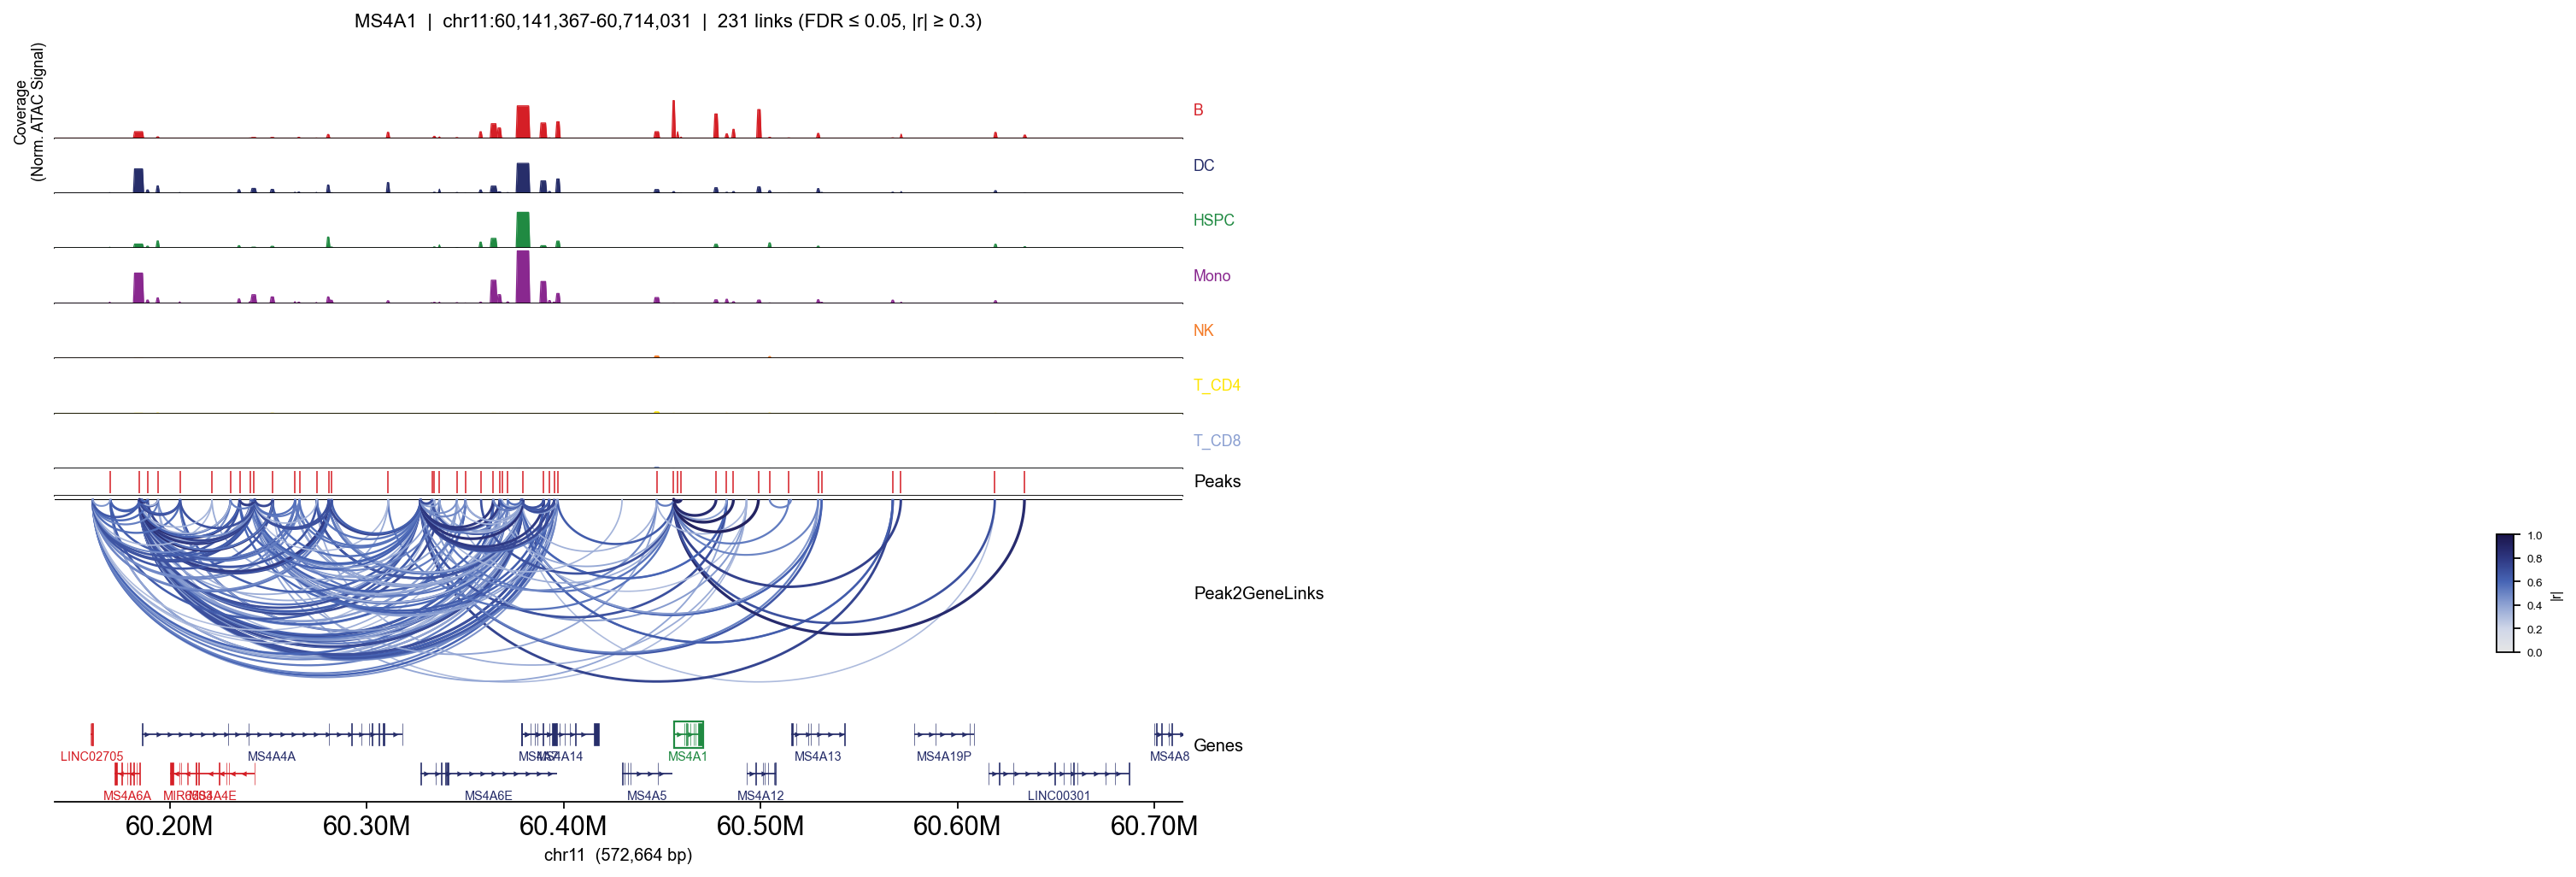

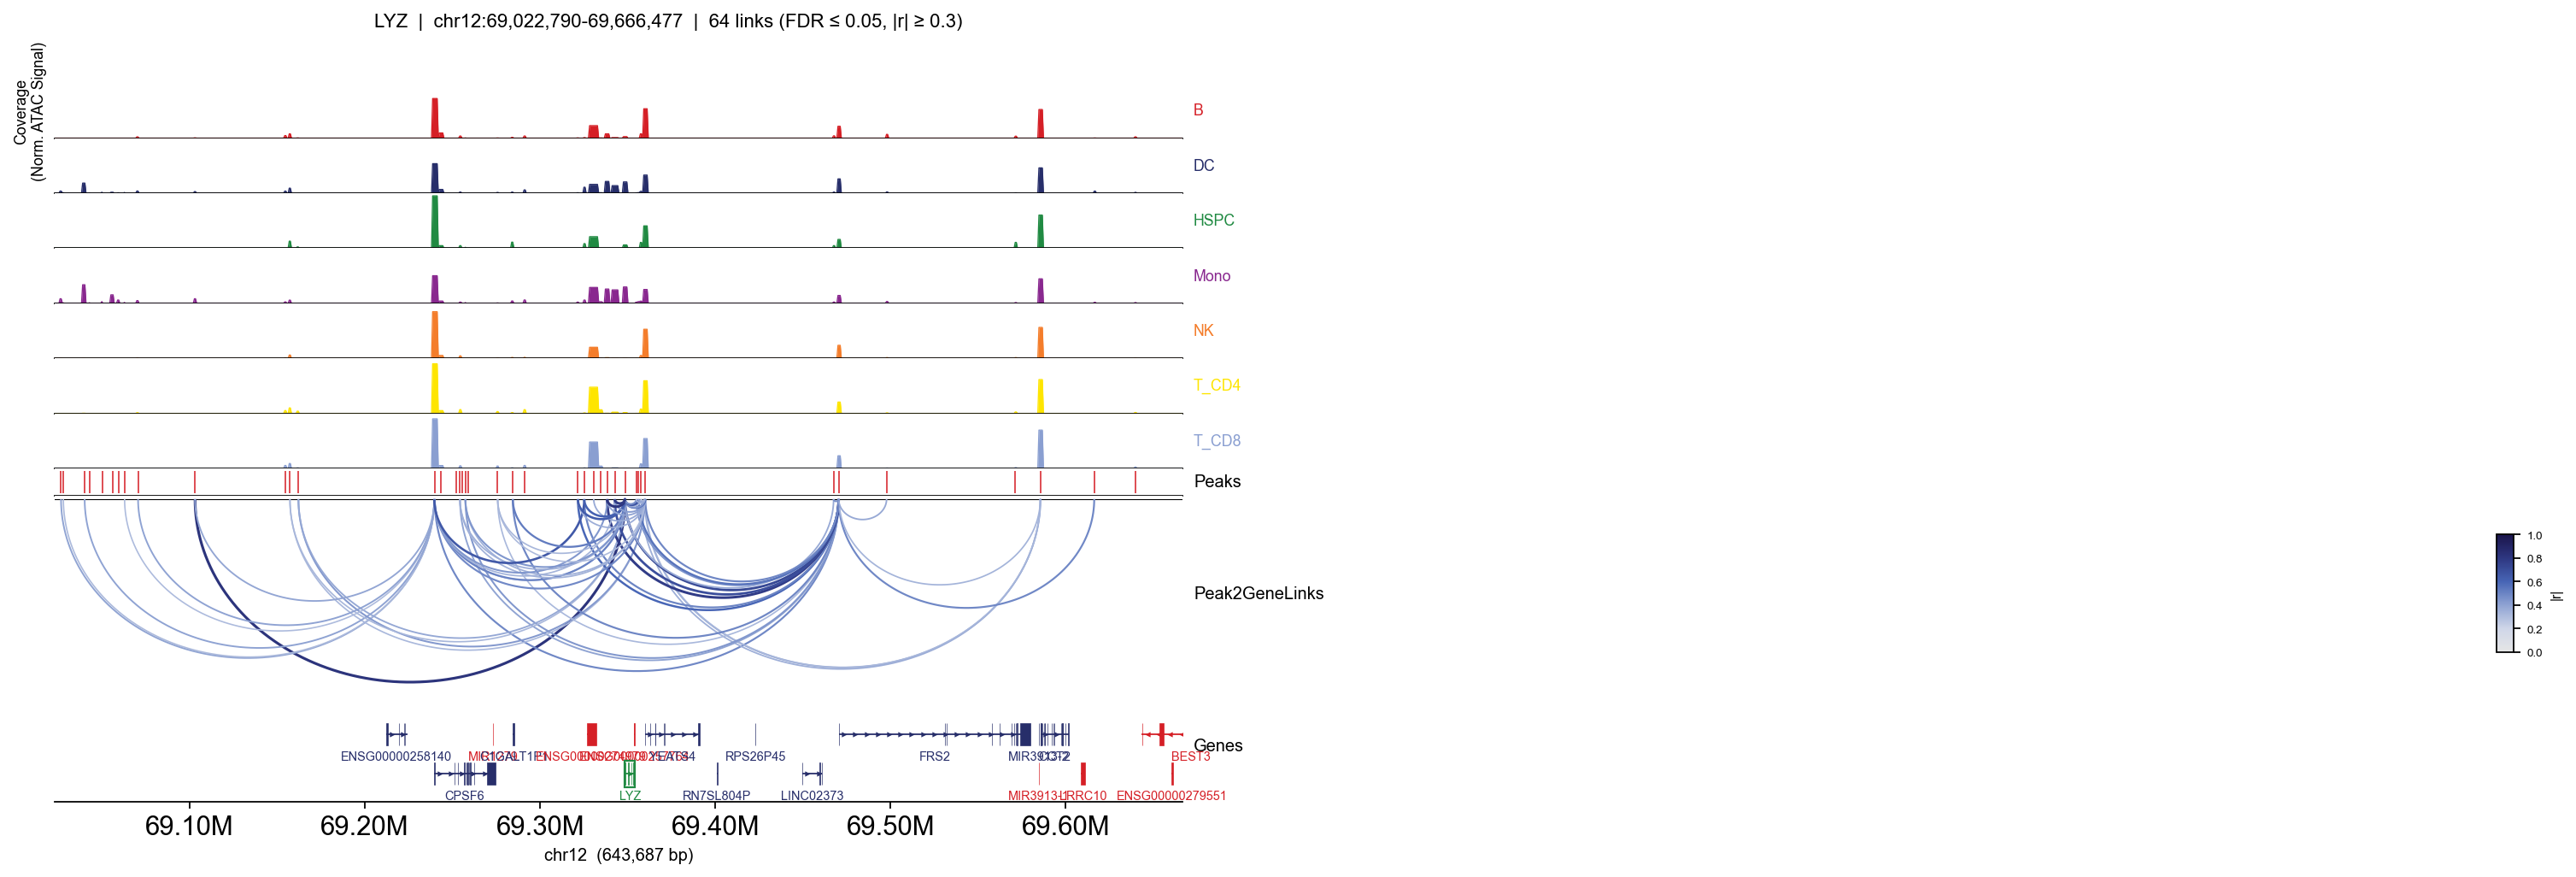

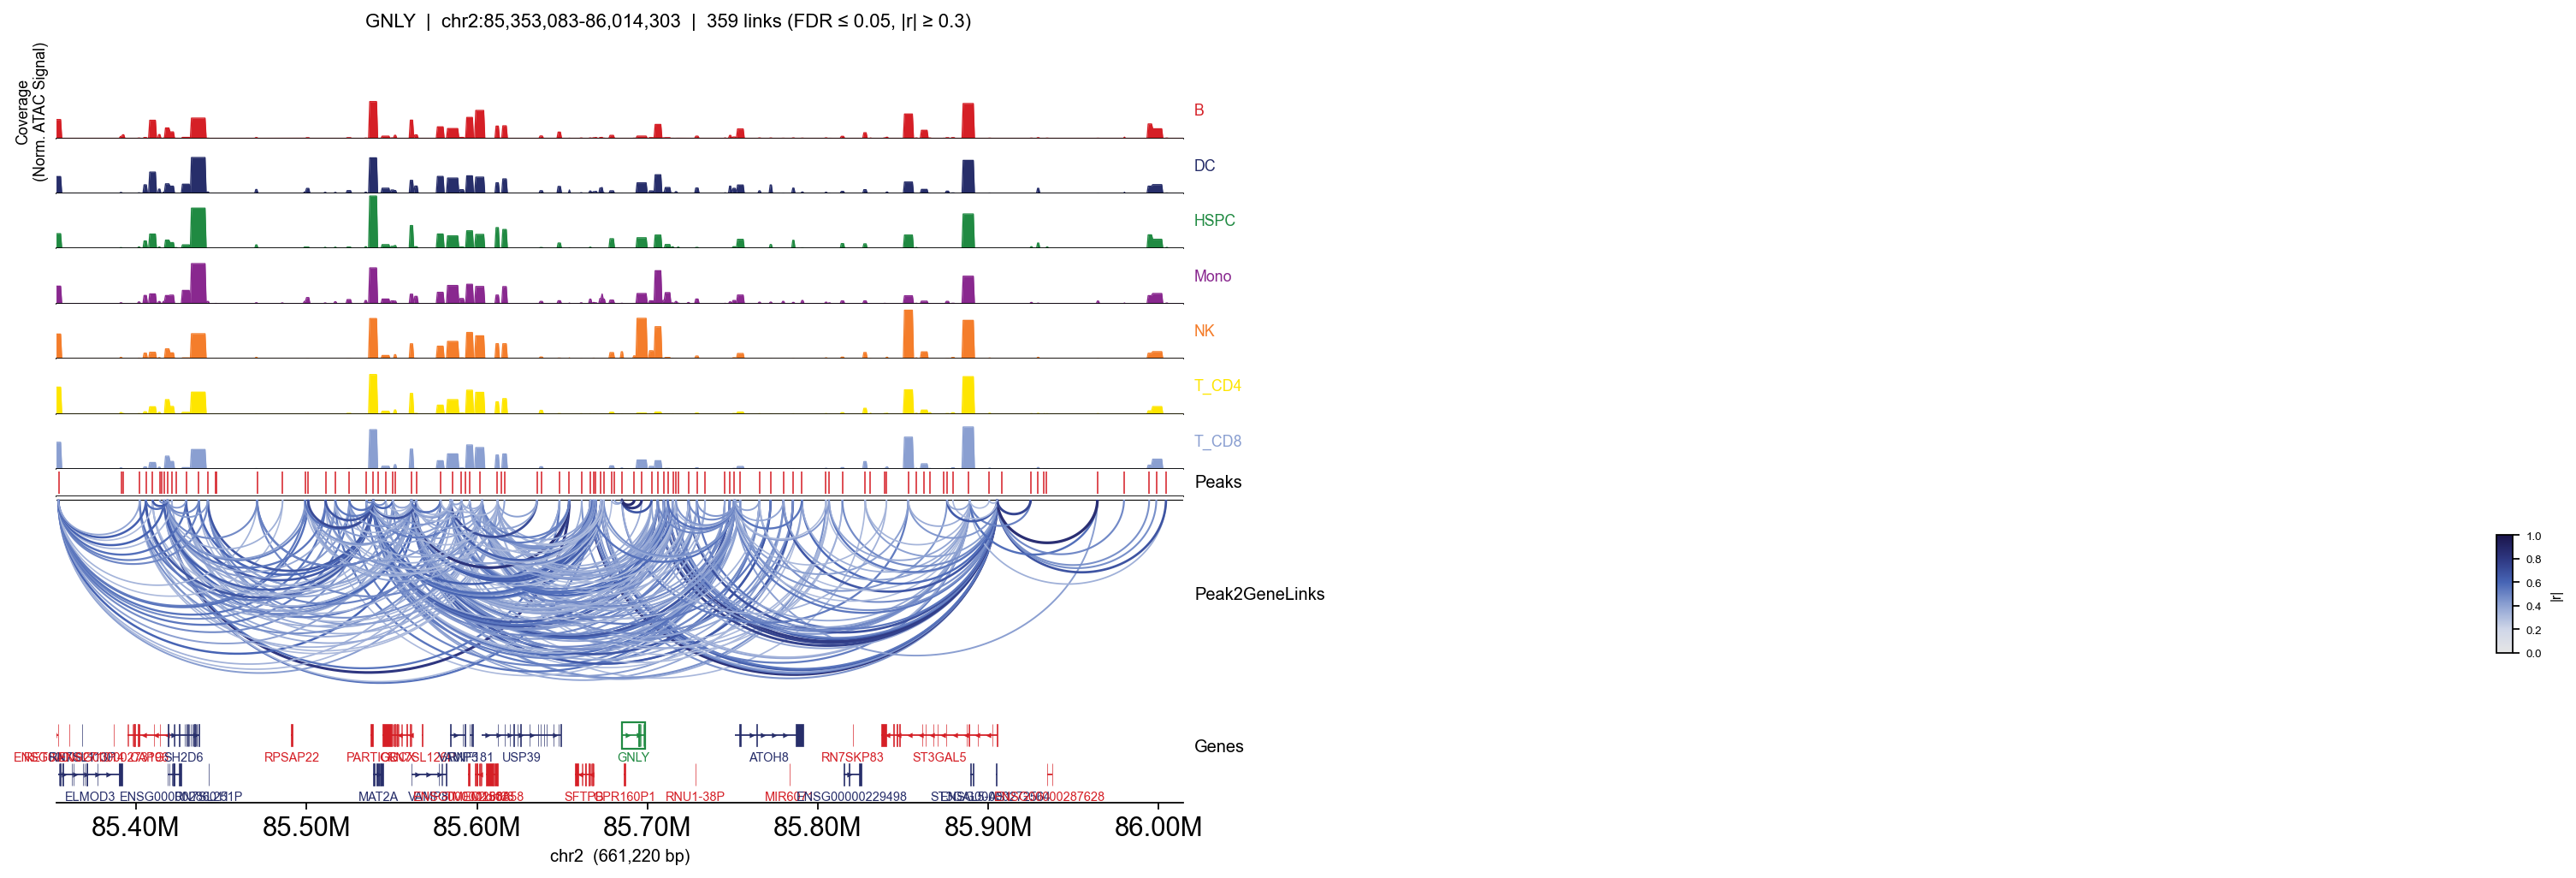

In [12]:
for gene in ['CD3D', 'MS4A1', 'LYZ', 'GNLY']:
    fig, _ = epi.pl.plot_peak2gene(
        atac, gene=gene,
        group_by='lineage',
        gene_annotation=gene_ann,
        exon_annotation=exon_ann,
        fdr_thresh=0.05, min_abs_r=0.3,
        pad_bp=80_000, figsize=(10, 6), show=False,
    )
    plt.tight_layout(); display(fig); plt.close(fig)


## Notes

- No RNA? Pass a gene-score / gene-activity matrix instead via `gene_obsm='X_gene_score'` + `gene_names=...`. API is otherwise identical.
- Memory scales with *candidate pairs*, not cells. 250 kb × 20k genes → ≈20 hits/peak, ~`n_peaks × 20` float32.
- `n_metacells=500, k_neighbors=100` matches ArchR; bump both for higher resolution at the cost of RAM.
- Arcs use ArchR's exact `getArchDF` half-ellipse geometry (`ry = R_MAX · rx / max_rx`); gene track follows the UCSC convention (intron line + exon blocks + strand chevrons) when `exon_annotation=` is provided.
